In [48]:


# pandas as numpy the goats
import pandas as pd
import numpy as np

#plotting and stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import IterativeImputer
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score

from collections import defaultdict

#for file handling
import glob 
import os
import re
import json
import warnings


In [ ]:
variables = [

    # Pillar 1: Education 
    "c11_math_income",
    "c11_reading_income",
    "c11_havo_test_income",
    "c11_vwo_test_income",
    "c11_vmbo_gl_test_income",
    "c11_over_advice_income",
    "c11_under_advice_income",
    "c11_class_size_income",
    "c16_havo_income",
    "c11_vwo_final_income",
    "c11_vmbo_gl_final_income",
    "c21_high_school_attained_income",
    "c21_hbo_followed_income",
    "c21_uni_followed_income",
    "c30_hbo_attained_income",

    # Pillar 3: Health & Well-being
    "c00_infant_mortality_income",
    "c00_neonatal_mortality_income",
    "c00_perinatal_mortality_income",
    "c00_preterm_birth_income",
    "c00_sga_income",
    "c30_basic_mhc_income",
    "c30_specialist_mhc_income",
    "c30_pharma_income",
    "c30_hospital_income",
    "c30_disability_income",
    "c16_youth_health_costs_income",
    "c30_total_health_costs_income",
    "c11_youth_protection_income",

    # Pillar 3: Living Conditions & Housing
    "c30_living_space_pp_income",
    "c30_homeowner_income",
    "c30_home_wealth_income",
    "c30_age_left_parents_income",
    #"c21_living_with_parents_income",
    
    

    # Pillar 4: Work & Income
    "c30_employed_income",
    "c30_hrs_work_pw_income",
    "c30_permanent_contract_income",
    "c30_hourly_wage_income",
    
    "c30_income_perc_income",
    "c30_household_income_perc_income",
    
    "c30_debt_income",
    "c30_social_assistance_income",
    "c30_wealth_income",
    
    
]

In [50]:
def get_files(vars, columns_keep):


    # Group files by folder
    folder_files = defaultdict(list)
    for file in glob.glob("R_1_0_M_1/**/*.csv", recursive=True):
        
      
        
        if any(var in os.path.basename(file) for var in vars):
            folder = os.path.dirname(file)
            folder_files[folder].append(file)

    
    files = [sorted(file_list)[0] for file_list in folder_files.values()]

    old_results = pd.DataFrame()
    for file in files: 
        
            try:
                
                df = pd.read_csv(file, low_memory=False)
                df = df[(df['type'] == 'municipality') | (df['type'] == 'neighborhood')]
                df = df[df['gemeentenaam'] == 'Amsterdam']
                
                var = df['outcome'].iloc[0]

                #keep wanted columns + name
                if columns_keep:

                    results = df[columns_keep + ['name']]
                    #add columnn with variable name
                    results['variable'] = var
                
                if old_results.empty:
                    old_results = results
                    
                else:
                    #CONCATENATE THE RESULTs
        
                    results = pd.concat([old_results, results], ignore_index=True)
                    old_results = results

                
            except Exception as e:
                print(f"Error processing file {file}: {e}")
                continue
                
    return results

master_df = get_files(variables, ['all_all_all_all', 'low_all_all_all', 'mid_all_all_all', 'high_all_all_all'])

display(master_df)

C:\Users\cleme\AppData\Local\Temp\ipykernel_3484\1211485061.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['variable'] = var
C:\Users\cleme\AppData\Local\Temp\ipykernel_3484\1211485061.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['variable'] = var
C:\Users\cleme\AppData\Local\Temp\ipykernel_3484\1211485061.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in

,all_all_all_all,low_all_all_all,mid_all_all_all,high_all_all_all,name,variable
0,0.97,NaN,NaN,NaN,Osdorp-Oost,c00_infant_mortality
1,0.78,NaN,NaN,NaN,Geuzenveld,c00_infant_mortality
2,0.50,NaN,NaN,NaN,Landlust,c00_infant_mortality
3,1.46,NaN,NaN,NaN,Venserpolder,c00_infant_mortality
4,0.81,NaN,NaN,NaN,Hoofdweg e.o.,c00_infant_mortality
...,...,...,...,...,...,...
3237,32226.00,33954.0,NaN,NaN,De Kolenkit,c30_wealth
3238,49795.00,NaN,NaN,NaN,Schinkelbuurt,c30_wealth
3239,30241.00,NaN,NaN,NaN,Tuindorp Buiksloot,c30_wealth
3240,93471.00,NaN,NaN,NaN,Driemond,c30_wealth


In [51]:
# ============================================================
# 0. LOAD AND RESHAPE DATA
# ============================================================



#Reshape the data frame for better clarity
master_df_long = master_df.copy()  

# Rename columns 
master_df_long.columns = ['total', 'low', 'mid', 'high', 'name', 'variable']

print("\nUnique variables:", master_df_long['variable'].nunique())
print("Unique neighborhoods:", master_df_long['name'].nunique())

# Pivot to wide format — one row per neighborhood, one column per variable per income group
df_total = master_df_long.pivot(index='name', columns='variable', values='total')
df_low   = master_df_long.pivot(index='name', columns='variable', values='low')
df_mid   = master_df_long.pivot(index='name', columns='variable', values='mid')
df_high  = master_df_long.pivot(index='name', columns='variable', values='high')

# Add suffix to distinguish income groups
df_total.columns = [f'{c}_total' for c in df_total.columns]
df_low.columns   = [f'{c}_low'   for c in df_low.columns]
df_mid.columns   = [f'{c}_mid'   for c in df_mid.columns]
df_high.columns  = [f'{c}_high'  for c in df_high.columns]

# Combine into one wide dataframe
master_df_long = pd.concat([df_total, df_low, df_mid, df_high], axis=1).reset_index()


display(master_df_long)


Unique variables: 41
Unique neighborhoods: 103


,name,c00_infant_mortality_total,c00_neonatal_mortality_total,c00_perinatal_mortality_total,c00_preterm_birth_total,c00_sga_total,c11_class_size_total,c11_havo_test_total,c11_math_total,c11_over_advice_total,...,c30_household_income_perc_high,c30_hrs_work_pw_high,c30_income_perc_high,c30_living_space_pp_high,c30_permanent_contract_high,c30_pharma_high,c30_social_assistance_high,c30_specialist_mhc_high,c30_total_health_costs_high,c30_wealth_high
0,Aetsveld/Oostelijke Vechtoever,NaN,NaN,NaN,7.51,7.51,26.0,44.88,40.12,22.93,...,54.90,31.3,52.68,42.6,72.53,60.73,NaN,NaN,1088.0,122133.0
1,Amsterdamse Poort e.o.,NaN,NaN,NaN,10.11,22.41,22.0,37.04,36.55,14.88,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Apollobuurt,NaN,NaN,NaN,4.68,10.77,27.0,74.67,62.70,22.48,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Banne Buiksloot,NaN,NaN,NaN,8.52,15.26,21.0,39.74,38.57,12.93,...,51.74,31.3,55.03,39.3,71.78,60.70,NaN,NaN,1129.0,208721.0
4,Bellamybuurt,NaN,NaN,NaN,7.10,15.26,25.0,46.81,42.68,18.09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,Westlandgracht,NaN,NaN,NaN,6.27,14.23,23.0,51.60,41.98,14.36,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99,Willemspark,NaN,NaN,NaN,6.49,8.14,26.0,77.11,73.17,19.90,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100,Zeeburgereiland/Bovendiep,NaN,NaN,NaN,NaN,12.87,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
101,Zuid Pijp,NaN,NaN,NaN,7.88,14.64,23.0,46.51,43.66,18.71,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
#provide extra data for later use
extra_df = pd.read_csv('extra_data/bbga_enriched.csv')

#add a 'total' at the end of the variable names in extra_df for easier merging
extra_df = extra_df.rename(columns=lambda x: f"{x}_total" if x != 'wijk_naam' else x)

#merge
master_df_long = pd.merge(master_df_long, extra_df, left_on='name', right_on='wijk_naam', how='left')

display(master_df_long)

,name,c00_infant_mortality_total,c00_neonatal_mortality_total,c00_perinatal_mortality_total,c00_preterm_birth_total,c00_sga_total,c11_class_size_total,c11_havo_test_total,c11_math_total,c11_over_advice_total,...,retail floor area in m2 of the number of points of sale per area where hous_total,retail floor area in m2 of the number of points of sale per area where leis_total,retail floor area in m2 of the number of sales points per area where other _total,retail floor area in m2 of the number of vacant points of sale_total,retail space daily products (food) / 1.000 residents_total,retail space total / 1.000 residents_total,student hbo_total,students mbo_total,students wo_total,total number of points of sale per area_total
0,Aetsveld/Oostelijke Vechtoever,NaN,NaN,NaN,7.51,7.51,26.0,44.88,40.12,22.93,...,1040.0,0.0,0.0,0.0,0.0,0.0,105.0,95.0,45.0,9.0
1,Amsterdamse Poort e.o.,NaN,NaN,NaN,10.11,22.41,22.0,37.04,36.55,14.88,...,983.0,968.0,1632.0,2429.0,3.0,8.0,535.0,380.0,970.0,189.0
2,Apollobuurt,NaN,NaN,NaN,4.68,10.77,27.0,74.67,62.70,22.48,...,535.0,424.0,223.0,65.0,3.0,8.0,100.0,20.0,265.0,120.0
3,Banne Buiksloot,NaN,NaN,NaN,8.52,15.26,21.0,39.74,38.57,12.93,...,115.0,0.0,142.0,55.0,1.0,2.0,355.0,475.0,275.0,40.0
4,Bellamybuurt,NaN,NaN,NaN,7.10,15.26,25.0,46.81,42.68,18.09,...,1495.0,75.0,823.0,734.0,4.0,11.0,125.0,45.0,280.0,233.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,Westlandgracht,NaN,NaN,NaN,6.27,14.23,23.0,51.60,41.98,14.36,...,40.0,400.0,0.0,140.0,1.0,1.0,635.0,235.0,1500.0,51.0
99,Willemspark,NaN,NaN,NaN,6.49,8.14,26.0,77.11,73.17,19.90,...,505.0,235.0,43.0,225.0,3.0,5.0,70.0,15.0,205.0,98.0
100,Zeeburgereiland/Bovendiep,NaN,NaN,NaN,NaN,12.87,NaN,NaN,NaN,NaN,...,500.0,90.0,0.0,0.0,0.0,1.0,355.0,100.0,590.0,21.0
101,Zuid Pijp,NaN,NaN,NaN,7.88,14.64,23.0,46.51,43.66,18.71,...,90.0,45.0,208.0,105.0,1.0,2.0,175.0,125.0,255.0,69.0


In [131]:
# ============================================================
# 1. VARIABLE DEFINITIONS PER PILLAR (base names)
# ============================================================

health_base = [
    
    # Self-reported health
    'Health: % (very) good',
    'Health: % serious psychological problems',
    
    # Lifestyle behaviours
    'Health: % smokers',
    'Life style: % overweight or obese (adults)',
    'Life style: % meets activity standard',
]

education_base = [
    'c11_class_size', 'c11_havo_test', 'c11_math', 'c11_over_advice',
    'c11_reading', 'c11_under_advice', 'c11_vmbo_gl_final',
    'c11_vmbo_gl_test', 'c11_vwo_final', 'c11_vwo_test', 'c16_havo',
    'c21_hbo_followed', 'c21_high_school_attained', 'c21_uni_followed', 'c30_hbo_attained',
    
    # Attainment outcomes
    'Primary education: school advice vwo (%)',
    'Primary education: school advice pro/vmbo-bk (%)',
   
    '18-22 yrs.: low qualified school leaver (%)',
    
    # Socioeconomic background
    'Primary education: students with hbo/wo educated parents (%)',
    'Primary education: students with primary school educated parents (%)',
    
    # Participation
    '18-22 yrs.: in education (%)',
    '18-22 yrs.: basic qualification (%)'

    
]

income_base = [
    # Income level
    'Mean disposable household income',
    'c30_household_income_perc',
    'c30_wealth',
    
    # Inequality
    'Gini coefficient income',
    'Low income households (130% sm) (%)',
    
    # Employment quality
    'c30_hourly_wage',
    
    # Deprivation
    'Social welfare (%)',
    'Househoulds children social welfare benefits (%)',
]

housing_base = [
    # Objective housing conditions
    'c30_living_space_pp',
    'c30_homeowner',
    'Cramped living (%)',
    'House too small (%)',
    
    # Affordability
    'Perceived affordability of total housing costs (scale 1–10)',
    
    # Neighbourhood quality
    'Neighbourhood: Satisfaction with neighbourhood (1-10)',
]

pillars_base = {
    'health': health_base,
    'education': education_base,
    'income': income_base,
    'housing': housing_base
}

income_groups = ['total', 'low', 'mid', 'high']

In [132]:
# ============================================================
# STAGE 2 — MISSINGNESS ANALYSIS
# ============================================================

print("STAGE 2 — MISSINGNESS ANALYSIS")


def analyse_missingness(df, base_vars, pillar_name, group):
    results = []
    for base in base_vars:
        col = f'{base}_{group}'
        if col not in df.columns:
            continue
        total = len(df)
        missing = df[col].isna().sum()
        pct = round(missing / total * 100, 2)

        if pct == 0:
            mechanism = 'Complete'
            treatment = 'None needed'
        elif pct > 40:
            mechanism = 'MNAR'
            treatment = 'Exclude'
        else:
            mechanism = 'MAR'
            treatment = 'MICE imputation'

        results.append({
            'pillar': pillar_name,
            'group': group,
            'column': col,
            'pct_missing': pct,
            'mechanism': mechanism,
            'treatment': treatment
        })
    return pd.DataFrame(results)

all_miss = []
for group in income_groups:
    for pillar, base_vars in pillars_base.items():
        all_miss.append(analyse_missingness(master_df_long, base_vars, pillar, group))

missingness_report = pd.concat(all_miss, ignore_index=True)
missingness_report.to_csv('missingness_report.csv', index=False)

print("\nMissingness summary:")
print(missingness_report.groupby(['pillar', 'group', 'mechanism']).size().unstack(fill_value=0))

print("\nExcluded variables (MNAR > 40%):")
excluded = missingness_report[missingness_report['mechanism'] == 'MNAR']
print(excluded[['pillar', 'group', 'column', 'pct_missing']].to_string())

# Build valid column lists per group per pillar
valid_cols = {}
for group in income_groups:
    valid_cols[group] = {}
    for pillar, base_vars in pillars_base.items():
        keep = missingness_report[
            (missingness_report['group'] == group) &
            (missingness_report['pillar'] == pillar) &
            (missingness_report['mechanism'] != 'MNAR')
        ]['column'].tolist()
        valid_cols[group][pillar] = keep
        print(f"  {group} | {pillar}: {len(keep)} valid columns")

# MICE imputation
print("\nApplying MICE imputation...")
imputed_dfs = {}

for group in income_groups:
    all_valid = [c for cols in valid_cols[group].values() for c in cols]
    mar_cols = missingness_report[
        (missingness_report['group'] == group) &
        (missingness_report['mechanism'] == 'MAR')
    ]['column'].tolist()

    df_copy = master_df_long.copy()
    if mar_cols:
        imputer = IterativeImputer(max_iter=10, random_state=42)
        df_copy[mar_cols] = imputer.fit_transform(df_copy[mar_cols])

    imputed_dfs[group] = df_copy
    remaining = df_copy[all_valid].isna().sum().sum()
    print(f"  {group}: {remaining} missing values remaining after imputation")


STAGE 2 — MISSINGNESS ANALYSIS

Missingness summary:
mechanism        Complete  MAR  MNAR
pillar    group                     
education high          0    0    15
          low           0    0    15
          mid           0    0    15
          total         4   16     2
health    total         0    5     0
...                   ...  ...   ...
housing   total         1    5     0
income    high          0    0     3
          low           0    0     3
          mid           0    0     3
          total         4    3     0

[13 rows x 3 columns]

Excluded variables (MNAR > 40%):
       pillar  group                                                  column  pct_missing
10  education  total                                  c11_under_advice_total        67.96
21  education  total  Primary education: school advice pro/vmbo-bk (%)_total        50.49
40  education    low                                      c11_class_size_low        57.28
41  education    low                             

c:\Users\cleme\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


STAGE 2 — PCA PER PILLAR PER INCOME GROUP

--- TOTAL income group ---
  ⚠ health_total: PC1 = 59.6% | PC2 = 35.4% | top var: Health: % (very) good_total


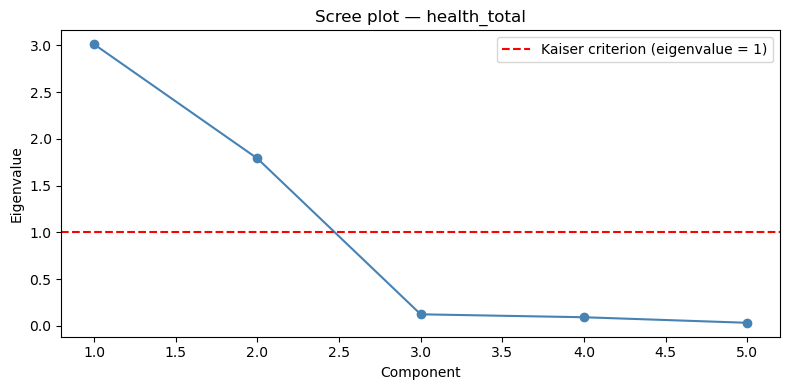

  ✓ education_total: PC1 = 76.0% (PC2 dropped) | top var: c16_havo_total


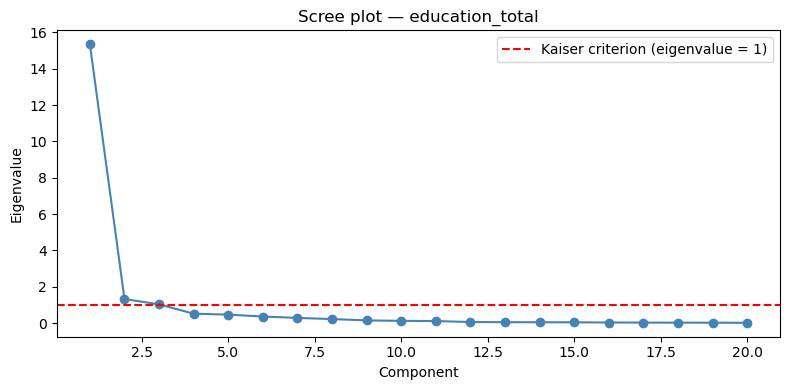

  ✓ income_total: PC1 = 72.3% (PC2 dropped) | top var: c30_hourly_wage_total


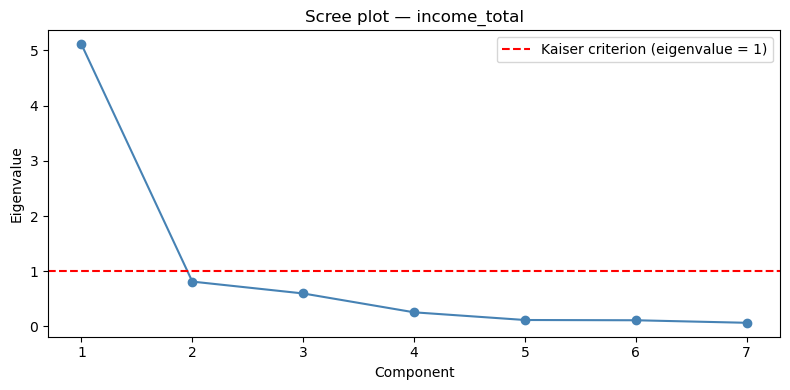

  ✓ housing_total: PC1 = 63.2% (PC2 dropped) | top var: Perceived affordability of total housing costs (scale 1–10)_total


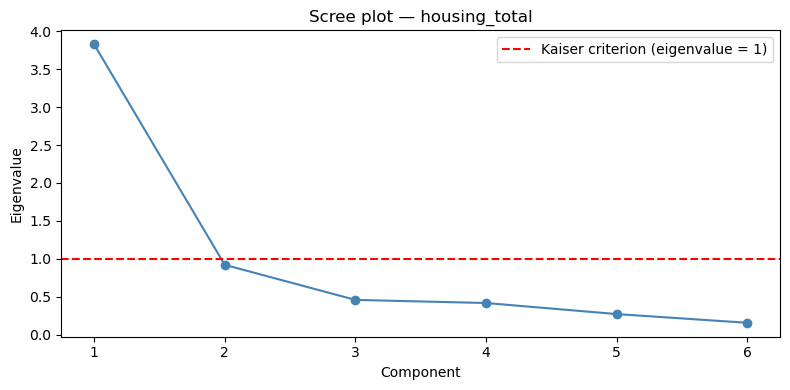


--- LOW income group ---
  Skipping health_low — insufficient data
  Skipping education_low — insufficient data
  Skipping income_low — insufficient data
  Skipping housing_low — insufficient data

--- MID income group ---
  Skipping health_mid — insufficient data
  Skipping education_mid — insufficient data
  Skipping income_mid — insufficient data
  Skipping housing_mid — insufficient data

--- HIGH income group ---
  Skipping health_high — insufficient data
  Skipping education_high — insufficient data
  Skipping income_high — insufficient data
  Skipping housing_high — insufficient data


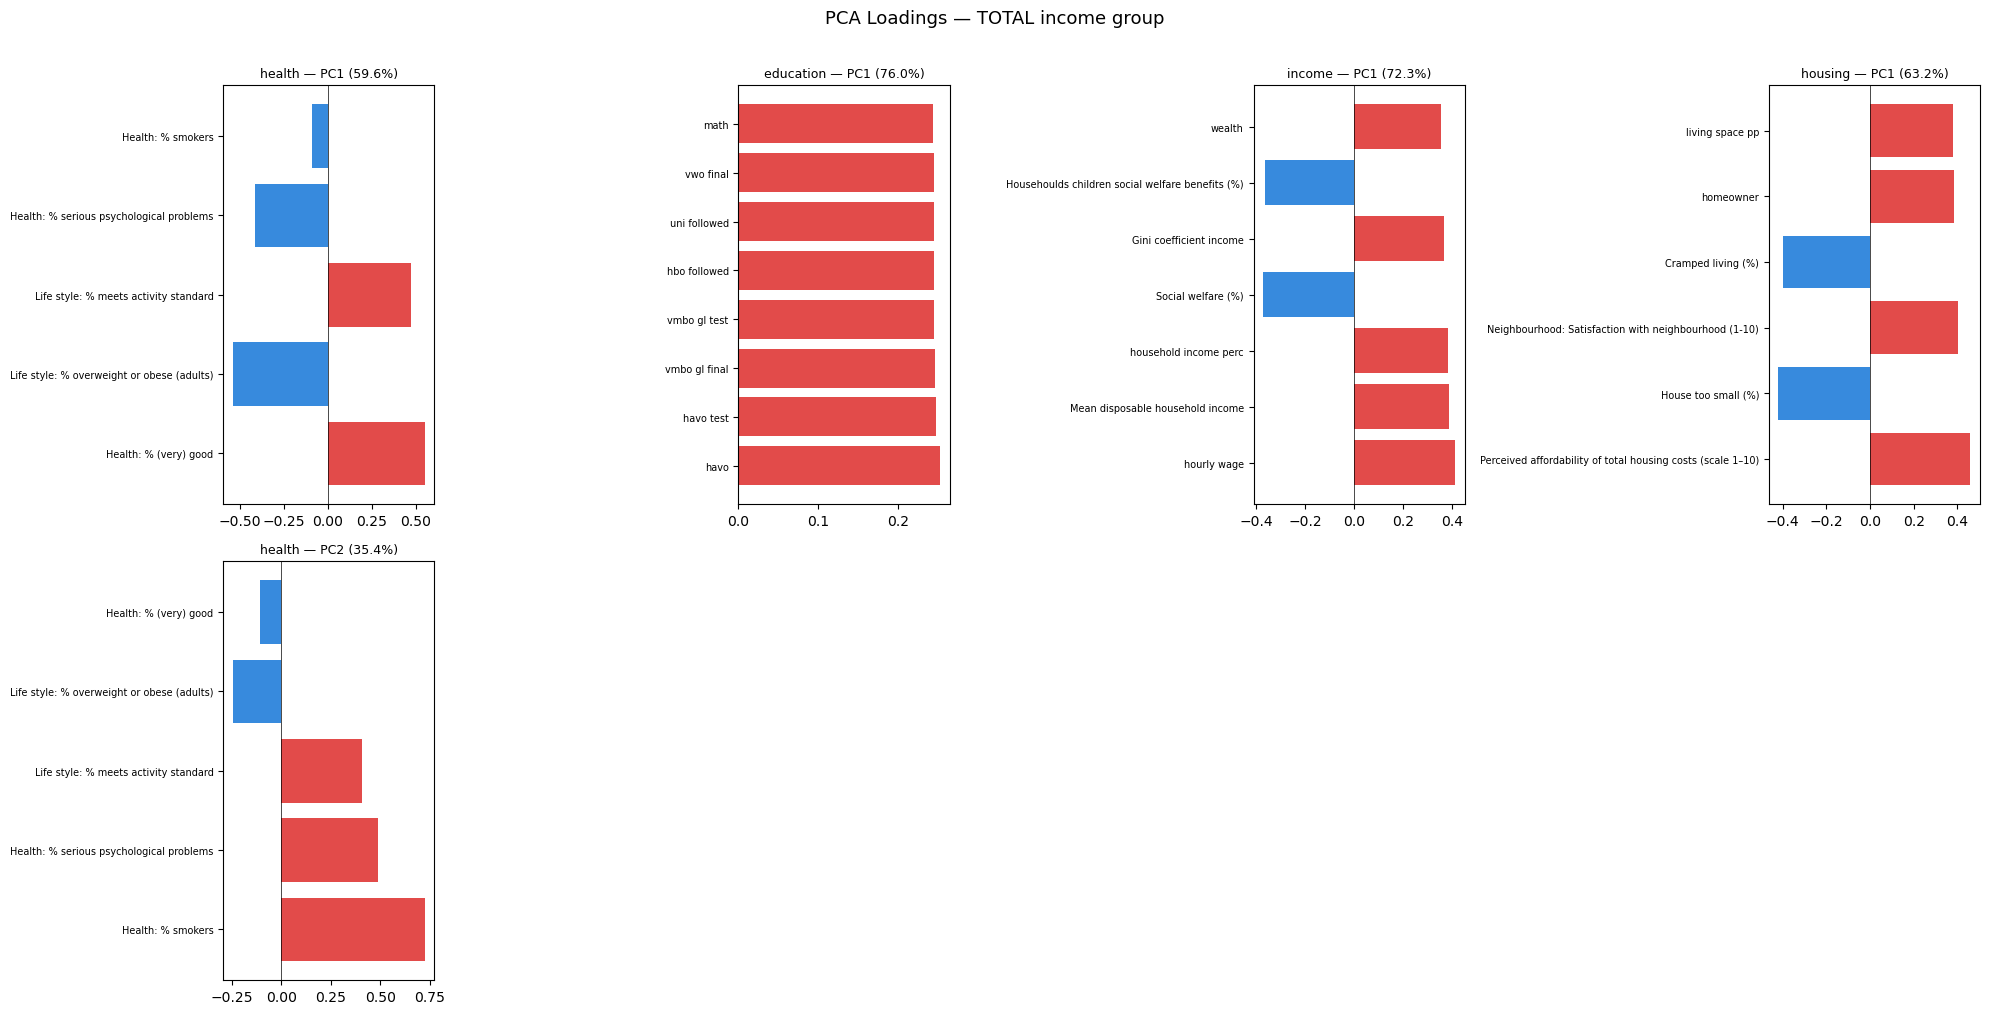

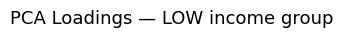

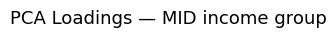

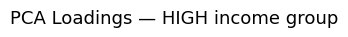

In [133]:
# ============================================================
# STAGE 2 — PCA PER PILLAR PER INCOME GROUP
# ============================================================

print("STAGE 2 — PCA PER PILLAR PER INCOME GROUP")

# Which pillars use PC2 in their combined index
USE_PC2 = {'health'}  # only health uses PC2

def run_pca(df, cols, label, pillar):
    available = [c for c in cols if c in df.columns and df[c].notna().sum() > 3]
    if len(available) < 2:
        print(f"  Skipping {label} — insufficient data")
        return None, None, None, None

    data = df[available].copy()
    scaler = StandardScaler()
    scaled = scaler.fit_transform(data)

    n_components = 2 if pillar in USE_PC2 else 1
    pca = PCA(n_components=n_components)
    scores = pca.fit_transform(scaled)

    expl_pc1 = pca.explained_variance_ratio_[0] * 100
    expl_pc2 = pca.explained_variance_ratio_[1] * 100 if n_components == 2 else None

    # Loadings dataframe
    component_cols = ['PC1', 'PC2'] if n_components == 2 else ['PC1']
    loadings_df = pd.DataFrame(
        pca.components_.T,
        index=available,
        columns=component_cols
    )

    top_var = loadings_df['PC1'].abs().sort_values(ascending=False).index[0]
    flag = '⚠' if expl_pc1 < 60 else '✓'

    if n_components == 2:
        print(f"  {flag} {label}: PC1 = {expl_pc1:.1f}% | PC2 = {expl_pc2:.1f}% | top var: {top_var}")
    else:
        print(f"  {flag} {label}: PC1 = {expl_pc1:.1f}% (PC2 dropped) | top var: {top_var}")

    # Scree plot — always refit with all components
    pca_full = PCA()
    pca_full.fit(scaled)
    plt.figure(figsize=(8, 4))
    plt.plot(
        range(1, len(pca_full.explained_variance_) + 1),
        pca_full.explained_variance_,
        'o-', color='steelblue'
    )
    plt.axhline(y=1, color='red', linestyle='--', label='Kaiser criterion (eigenvalue = 1)')
    plt.xlabel('Component')
    plt.ylabel('Eigenvalue')
    plt.title(f'Scree plot — {label}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    pc1 = scores[:, 0]
    pc2 = scores[:, 1] if n_components == 2 else None

    return pc1, pc2, (expl_pc1, expl_pc2), loadings_df


# ── Store results ─────────────────────────────────────────────────────────────
pca_scores = {}
pca_loadings = {}

for group in income_groups:
    print(f"\n--- {group.upper()} income group ---")
    pca_scores[group] = {}
    pca_loadings[group] = {}

    for pillar in pillars_base.keys():
        cols = valid_cols[group][pillar]
        pc1, pc2, expl, loadings_df = run_pca(imputed_dfs[group], cols, f'{pillar}_{group}', pillar)

        if pc1 is not None:
            pca_scores[group][pillar] = {'pc1': pc1, 'pc2': pc2}
            pca_loadings[group][pillar] = {
                'explained_variance_pc1': expl[0],
                'explained_variance_pc2': expl[1],  # None for PC1-only pillars
                'loadings': loadings_df,
                'top_variables': loadings_df['PC1'].abs().sort_values(ascending=False).index[:3].tolist(),
                'uses_pc2': pillar in USE_PC2,
            }


# ── Build scores dataframe per group ─────────────────────────────────────────
scores_dfs = {}

for group in income_groups:
    df_scores = master_df_long[['name']].copy()

    for pillar in pillars_base.keys():
        if pillar not in pca_scores[group]:
            continue

        info  = pca_loadings[group][pillar]
        pc1   = pca_scores[group][pillar]['pc1']
        pc2   = pca_scores[group][pillar]['pc2']
        ev1   = info['explained_variance_pc1']

        df_scores[f'{pillar}_pc1'] = pc1

        if info['uses_pc2'] and pc2 is not None:
            ev2 = info['explained_variance_pc2']
            combined = (pc1 * ev1 + pc2 * ev2) / (ev1 + ev2)
            df_scores[f'{pillar}_pc2']   = pc2
        else:
            combined = pc1

        df_scores[f'{pillar}_index'] = combined
        df_scores[f'{pillar}_score'] = (
            df_scores[f'{pillar}_index'].rank(pct=True) * 100
        ).round(2)

    scores_dfs[group] = df_scores





# ── Visualise loadings ────────────────────────────────────────────────────────
for group in income_groups:
    # For PC2 pillars we need 2 rows, otherwise 1
    n_rows = 2 if USE_PC2 else 1
    fig, axes = plt.subplots(n_rows, len(pillars_base), figsize=(20, 5 * n_rows))
    if n_rows == 1:
        axes = [axes]  # make indexing consistent
    fig.suptitle(f'PCA Loadings — {group.upper()} income group', fontsize=13, y=1.01)

    for j, pillar in enumerate(pillars_base.keys()):
        if pillar not in pca_loadings[group]:
            for row in axes:
                row[j].set_visible(False)
            continue

        info     = pca_loadings[group][pillar]
        loadings = info['loadings']
        ev1      = info['explained_variance_pc1']
        uses_pc2 = info['uses_pc2']

        # Always plot PC1
        top = loadings['PC1'].abs().sort_values(ascending=False).head(8)
        vals = loadings.loc[top.index, 'PC1']
        colors = ['#E24B4A' if x > 0 else '#378ADD' for x in vals]
        short = [re.sub(r'c\d+_', '', c).replace(f'_{group}', '').replace('_', ' ')
                 for c in vals.index]
        axes[0][j].barh(range(len(vals)), vals.values, color=colors)
        axes[0][j].set_yticks(range(len(vals)))
        axes[0][j].set_yticklabels(short, fontsize=7)
        axes[0][j].set_title(f'{pillar} — PC1 ({ev1:.1f}%)', fontsize=9)
        axes[0][j].axvline(0, color='black', linewidth=0.5)

        # Plot PC2 only for health
        if n_rows == 2:
            if uses_pc2 and 'PC2' in loadings.columns:
                ev2 = info['explained_variance_pc2']
                top2 = loadings['PC2'].abs().sort_values(ascending=False).head(8)
                vals2 = loadings.loc[top2.index, 'PC2']
                colors2 = ['#E24B4A' if x > 0 else '#378ADD' for x in vals2]
                short2 = [re.sub(r'c\d+_', '', c).replace(f'_{group}', '').replace('_', ' ')
                          for c in vals2.index]
                axes[1][j].barh(range(len(vals2)), vals2.values, color=colors2)
                axes[1][j].set_yticks(range(len(vals2)))
                axes[1][j].set_yticklabels(short2, fontsize=7)
                axes[1][j].set_title(f'{pillar} — PC2 ({ev2:.1f}%)', fontsize=9)
                axes[1][j].axvline(0, color='black', linewidth=0.5)
            else:
                axes[1][j].set_visible(False)

    plt.tight_layout()
    plt.show()

In [134]:
# Check direction — do known deprived neighborhoods score high or low?
known_deprived = ['De Kolenkit', 'Geuzenveld', 'Venserpolder']
known_affluent = ['Grachtengordel-West', 'Museumkwartier', 'Willemspark']

print("\nDirection check:")
for group in ['total']:
    df = scores_dfs[group]
    print(f"\nDeprived neighborhoods:")
    print(df[df['name'].isin(known_deprived)][score_cols].to_string())
    print(f"\nAffluent neighborhoods:")
    print(df[df['name'].isin(known_affluent)][score_cols].to_string())


Direction check:

Deprived neighborhoods:
            name  health_score  education_score  income_score  housing_score
18   De Kolenkit         38.83            14.56         23.30           5.83
30    Geuzenveld         24.27            15.53         29.13           8.74
88  Venserpolder          6.80             1.94          4.85          17.48

Affluent neighborhoods:
                   name  health_score  education_score  income_score  housing_score
31  Grachtengordel-West         96.60            99.03         94.17          83.50
52       Museumkwartier         81.55           100.00         97.09          91.26
99          Willemspark         78.64            95.15         95.15          92.23


STAGE 3 — CLUSTER ANALYSIS
Clustering: 103 neighborhoods x 4 pillars


c:\Users\cleme\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\cleme\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\cleme\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\cleme\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

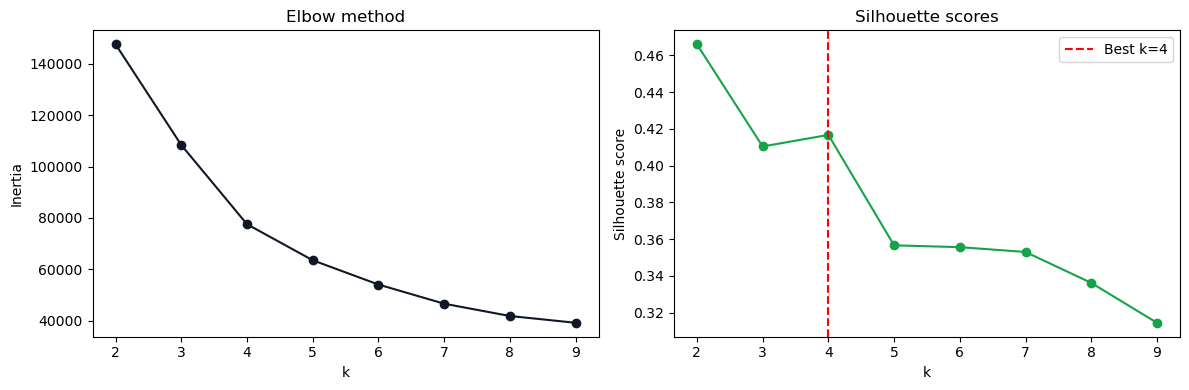

Best k by silhouette: 4


c:\Users\cleme\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


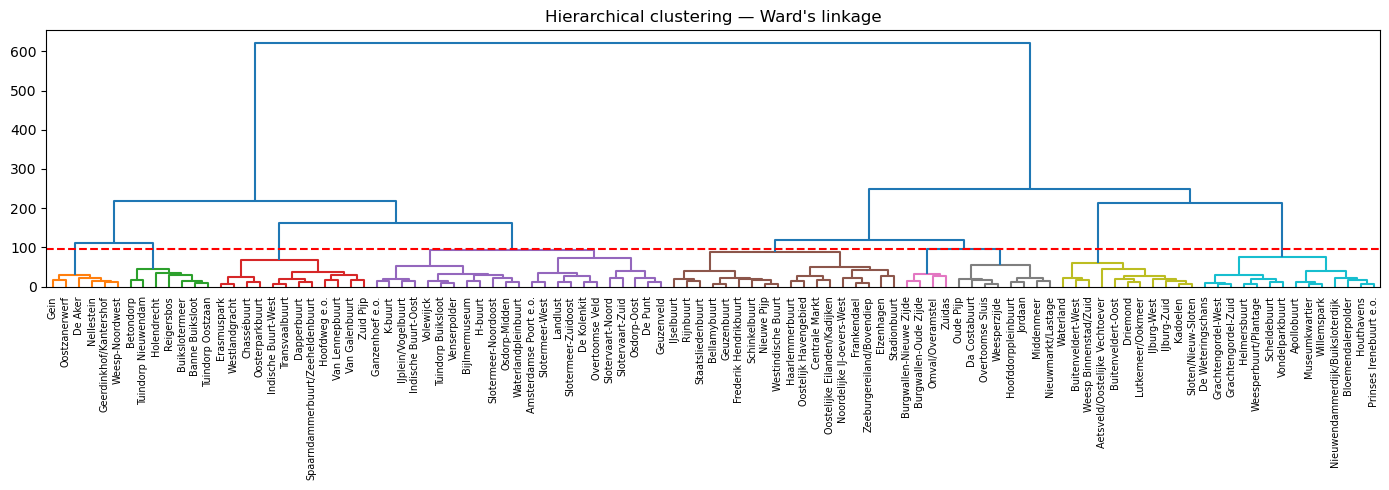


K-means cluster profiles:
                health_score  education_score  income_score  housing_score
cluster_kmeans                                                            
0                      76.02            90.05         87.23          83.64
1                      28.64            19.88         19.24          24.14
2                      75.13            64.14         55.68          45.20
3                      25.79            48.97         69.36          81.19


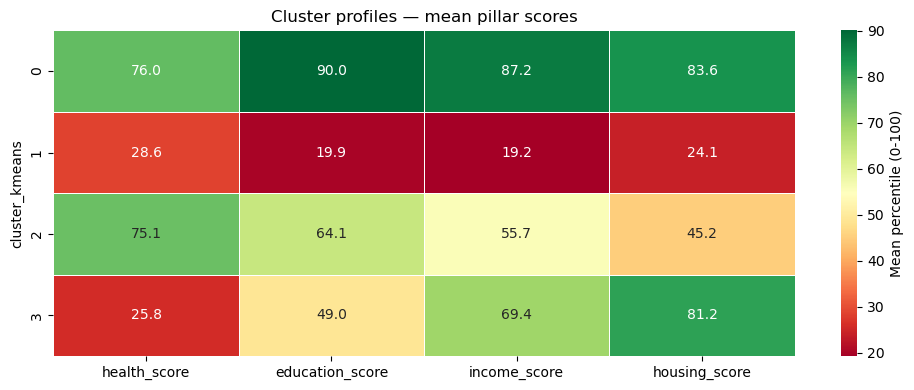


Neighborhoods per cluster:

Cluster 0: ['Apollobuurt', 'Bloemendalerpolder', 'De Weteringschans', 'Grachtengordel-West', 'Grachtengordel-Zuid', 'Haarlemmerbuurt', 'Helmersbuurt', 'Hoofddorppleinbuurt', 'Houthavens', 'Jordaan', 'Middenmeer', 'Museumkwartier', 'Nieuwendammerdijk/Buiksloterdijk', 'Nieuwmarkt/Lastage', 'Prinses Irenebuurt e.o.', 'Scheldebuurt', 'Vondelparkbuurt', 'Waterland', 'Weesperbuurt/Plantage', 'Willemspark']

Cluster 1: ['Amsterdamse Poort e.o.', 'Banne Buiksloot', 'Betondorp', 'Bijlmermuseum', 'Buikslotermeer', 'Dapperbuurt', 'De Kolenkit', 'De Punt', 'Ganzenhoef e.o.', 'Geuzenveld', 'H-buurt', 'Holendrecht', 'Hoofdweg e.o.', 'IJplein/Vogelbuurt', 'Indische Buurt-Oost', 'Indische Buurt-West', 'K-buurt', 'Landlust', 'Osdorp-Midden', 'Osdorp-Oost', 'Overtoomse Veld', 'Reigersbos', 'Slotermeer-Noordoost', 'Slotermeer-West', 'Slotermeer-Zuidoost', 'Slotervaart-Noord', 'Slotervaart-Zuid', 'Spaarndammerbuurt/Zeeheldenbuurt', 'Transvaalbuurt', 'Tuindorp Buiksloot', 'Tuin

In [135]:
# ============================================================
# STAGE 3 — CLUSTER ANALYSIS (on total group scores)
# ============================================================

print("STAGE 3 — CLUSTER ANALYSIS")


# Use total group scores for clustering
cluster_input_cols = [f'{p}_score' for p in pillars_base.keys()
                      if f'{p}_score' in scores_dfs['total'].columns]

cluster_df = scores_dfs['total'].dropna(subset=cluster_input_cols).copy()
X = cluster_df[cluster_input_cols].values

print(f"Clustering: {X.shape[0]} neighborhoods x {X.shape[1]} pillars")

# Elbow method
inertias, sil_scores = [], []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(k_range), inertias, marker='o', color='#101828')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia'); ax1.set_title('Elbow method')

ax2.plot(list(k_range), sil_scores, marker='o', color='#16A34A')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette score'); ax2.set_title('Silhouette scores')
best_k = list(k_range)[sil_scores.index(max(sil_scores))]

#hardcorde best k = 4
best_k = 4
ax2.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
ax2.legend()

plt.tight_layout()
plt.savefig('cluster_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best k by silhouette: {best_k}")



# K-means
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_df['cluster_kmeans'] = kmeans.fit_predict(X)

# Hierarchical
Z = linkage(X, method='ward')
cluster_df['cluster_hierarchical'] = fcluster(Z, t=best_k, criterion='maxclust')


n = len(cluster_df)
cut_height = Z[-(k-1), 2] * 0.99

# Dendrogram
plt.figure(figsize=(14, 5))
dendrogram(Z, labels=cluster_df['name'].values,
           leaf_rotation=90, leaf_font_size=7, color_threshold=cut_height)
plt.axhline(y=cut_height, color='red', linestyle='--', linewidth=1.5, label=f'Cut at k={k}')

plt.title("Hierarchical clustering — Ward's linkage")
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

# Cluster profiles
print("\nK-means cluster profiles:")
profile = cluster_df.groupby('cluster_kmeans')[cluster_input_cols].mean().round(2)
print(profile)

plt.figure(figsize=(10, 4))
sns.heatmap(profile, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, cbar_kws={'label': 'Mean percentile (0-100)'})
plt.title('Cluster profiles — mean pillar scores')
plt.tight_layout()

plt.show()

print("\nNeighborhoods per cluster:")
for c in sorted(cluster_df['cluster_kmeans'].unique()):
    names = cluster_df[cluster_df['cluster_kmeans'] == c]['name'].tolist()
    print(f"\nCluster {c}: {names}")


In [136]:


# Compare the two solutions
ari = adjusted_rand_score(cluster_df['cluster_kmeans'], cluster_df['cluster_hierarchical'])
print(f"Adjusted Rand Index (agreement): {ari:.3f}")
# 1.0 = perfect agreement, 0.0 = random

# See which neighborhoods disagree
cluster_df['agree'] = cluster_df['cluster_kmeans'] == cluster_df['cluster_hierarchical']
disagreements = cluster_df[~cluster_df['agree']][['name', 'cluster_kmeans', 'cluster_hierarchical']]
print(f"\nNeighborhoods where solutions disagree ({len(disagreements)}):")
print(disagreements.to_string())

Adjusted Rand Index (agreement): 0.568

Neighborhoods where solutions disagree (92):
                                 name  cluster_kmeans  cluster_hierarchical
0      Aetsveld/Oostelijke Vechtoever               3                     4
1              Amsterdamse Poort e.o.               1                     2
2                         Apollobuurt               0                     4
4                        Bellamybuurt               2                     3
6                       Bijlmermuseum               1                     2
7                  Bloemendalerpolder               0                     4
9                  Buitenveldert-Oost               3                     4
10                 Buitenveldert-West               3                     4
11            Burgwallen-Nieuwe Zijde               2                     3
12              Burgwallen-Oude Zijde               2                     3
13                     Centrale Markt               2                     3
15 

In [138]:


neighborhood_drivers = defaultdict(lambda: defaultdict(dict))

for group in income_groups:
    imputed_dfs[group] = imputed_dfs[group].loc[:, ~imputed_dfs[group].columns.duplicated()]
    df_group = imputed_dfs[group].reset_index(drop=True)  # fix duplicate index
    
    for pillar, base_vars in pillars_base.items():
        cols = [f'{v}_{group}' for v in base_vars if f'{v}_{group}' in df_group.columns]
        if not cols:
            continue
        
        city_means = df_group[cols].mean()
        city_stds  = df_group[cols].std()
        
        for _, row in df_group.iterrows():
            name = row['name']
            if isinstance(name, pd.Series):
                name = name.iloc[0]  # handle duplicate index on name too
            
            deviations = {}
            for col in cols:
                val = row[col]
               
                
                if pd.notna(val) and city_stds[col] > 0:
                    z = abs((float(val) - city_means[col]) / city_stds[col])
                    deviations[col] = z
            
            if not deviations:
                continue
            
            top3 = sorted(deviations, key=deviations.get, reverse=True)[:3]
            
            driver_vals = {}
            for var in top3:
                val = row[var]
                if isinstance(val, pd.Series):
                    val = val.iloc[0]
                driver_vals[var] = round(float(val), 3) if pd.notna(val) else None
            
            neighborhood_drivers[name][f'{pillar}_{group}'] = {
                'top_variables': top3,
                'values':        driver_vals,
                'deviations':    {v: round(deviations[v], 3) for v in top3}
            }

# Verify
sample_name = list(neighborhood_drivers.keys())[0]
print(f"Sample entry for {sample_name}:")
for pillar_group, data in neighborhood_drivers[sample_name].items():
    print(f"\n  {pillar_group}:")
    print(f"    Top variables: {data['top_variables']}")
    print(f"    Values:        {data['values']}")
    print(f"    Deviations:    {data['deviations']}")

Sample entry for Aetsveld/Oostelijke Vechtoever:

  health_total:
    Top variables: ['Health: % smokers_total', 'Life style: % meets activity standard_total', 'Life style: % overweight or obese (adults)_total']
    Values:        {'Health: % smokers_total': 12.394, 'Life style: % meets activity standard_total': 39.363, 'Life style: % overweight or obese (adults)_total': 56.881}
    Deviations:    {'Health: % smokers_total': 2.541, 'Life style: % meets activity standard_total': 2.305, 'Life style: % overweight or obese (adults)_total': 1.95}

  education_total:
    Top variables: ['c21_high_school_attained_total', 'Primary education: students with primary school educated parents (%)_total', 'c11_class_size_total']
    Values:        {'c21_high_school_attained_total': 88.01, 'Primary education: students with primary school educated parents (%)_total': 6.0, 'c11_class_size_total': 26.0}
    Deviations:    {'c21_high_school_attained_total': 1.19, 'Primary education: students with primary 

In [110]:
# ============================================================
# EXPORT FOR WEBSITE
# ============================================================

print("\n" + "="*60)
print("EXPORTING neighborhood_scores.json")
print("="*60)

export_rows = []

for _, row in scores_dfs['total'].iterrows():
    entry = {}
    name = row['name']
    entry['name'] = name

    # Scores per group
    for group in income_groups:
        group_row = scores_dfs[group][scores_dfs[group]['name'] == name]
        if not group_row.empty:
            group_row = group_row.iloc[0]
            for pillar in pillars_base.keys():
                col = f'{pillar}_score'
                if col in group_row.index and pd.notna(group_row[col]):
                    entry[f'{pillar}_score_{group}'] = round(float(group_row[col]), 2)

    # Default score (total) for backward compatibility
    for pillar in pillars_base.keys():
        col = f'{pillar}_score'
        if col in row.index and pd.notna(row[col]):
            entry[f'{pillar}_score'] = round(float(row[col]), 2)

    # Cluster
    match = cluster_df[cluster_df['name'] == name]
    if not match.empty:
        entry['cluster'] = int(match['cluster_kmeans'].values[0])

    # Per-neighborhood drivers — inline, using current name
    if name in neighborhood_drivers:
        for pillar_group, data in neighborhood_drivers[name].items():
            for var, val in data['values'].items():
                clean_var = re.sub(r'c\d+_', '', var)\
                    .replace('_income', '')\
                    .replace('_total', '')\
                    .replace('_low', '')\
                    .replace('_mid', '')\
                    .replace('_high', '')
                key = f'{pillar_group}_driver_{clean_var}'
                entry[key] = val
                

    export_rows.append(entry)

with open('neighborhood_scores.json', 'w') as f:
    json.dump(export_rows, f, indent=2)

print(f"Exported {len(export_rows)} neighborhoods")
print(f"First 3 names: {[r['name'] for r in export_rows[:3]]}")
print(f"Sample keys: {list(export_rows[0].keys())[:15]}")


EXPORTING neighborhood_scores.json
Exported 103 neighborhoods
First 3 names: ['Aetsveld/Oostelijke Vechtoever', 'Amsterdamse Poort e.o.', 'Apollobuurt']
Sample keys: ['name', 'health_score_total', 'education_score_total', 'income_score_total', 'housing_score_total', 'health_score', 'education_score', 'income_score', 'housing_score', 'cluster', 'health_total_driver_Health: % smokers', 'health_total_driver_Life style: % meets activity standard', 'health_total_driver_Life style: % overweight or obese (adults)']
